In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

# 1. Cargar datos

In [2]:
# Path relativo desde notebooks/ hasta data/results/
ruta_excel = "../data/results/similitudes_chunks.xlsx"

sim_df = pd.read_excel(ruta_excel)

# Identificar columnas de categorías (ajusta si es necesario)
subcat_cols = sim_df.columns[3:20]  # <- revisa si son las correctas
print("Columnas de categorías:", subcat_cols.tolist())


Columnas de categorías: ['Ciencias_ambientales_ingenieria', 'Ciencias_espacio', 'Ciencias_fisicas', 'Ciencias_Geografia_oceanografia', 'Ciencias_medicas', 'Ciencias_metereologia', 'Ciencias_naturales', 'Ciencias_polucion_catastrofes_seguridad', 'Ciencias_quimicas', 'Ciencias_tierra', 'Ciencia_Administracion_ciencia_investigacion', 'Ciencia_biologia', 'Ciencia_enfoque_cientifico', 'Ciencia_hidrologia', 'Ciencia_matematicas_estadistica', 'Ciencia_patologia', 'Ciencia_recursos_naturales']


# 2. Filtrar scores entre 0.3 y 0.7

In [3]:
sim_df["chunk_uid"] = sim_df["id_doc"].astype(str) + "_" + sim_df["chunk_id"].astype(str)

sim_temp = sim_df.copy()
for col in subcat_cols:
    sim_temp[col] = sim_temp[col].astype(float)

mask = (sim_temp[subcat_cols] >= 0.3) & (sim_temp[subcat_cols] <= 0.7)

# Para cada chunk, quedarse con la categoría de mayor score (si hay varias)
sim_filtered = []
for idx, row in sim_temp.iterrows():
    # Categorías válidas en rango
    valid_cats = [c for c in subcat_cols if mask.loc[idx, c]]
    if valid_cats:
        # Seleccionar la categoría con mayor score
        best_cat = max(valid_cats, key=lambda c: row[c])
        sim_filtered.append({
            "chunk_id": row["chunk_id"],
            "chunk_uid": row["chunk_uid"],
            "texto_chunk": row["texto_chunk"] if "texto_chunk" in row else None,
            "categoria": best_cat,
            "score": row[best_cat]
        })

sim_filtered = pd.DataFrame(sim_filtered)
print("Total de chunks elegibles:", len(sim_filtered))


Total de chunks elegibles: 14733


In [4]:
14733/35000

0.4209428571428571

# 3. Selección balanceada por categoría

In [5]:
selected_chunks = []

for cat in subcat_cols:
    candidatos = sim_filtered[sim_filtered["categoria"] == cat]

    if len(candidatos) > 7:
        muestra = candidatos.sample(7, random_state=111)
    else:
        muestra = candidatos  # si no hay suficientes, tomamos todos
    
    selected_chunks.append(muestra)

# Concatenar todas las muestras
final_selection = pd.concat(selected_chunks, ignore_index=True)

# 4. Evitar repeticiones

In [6]:
final_selection = final_selection.drop_duplicates(subset=["chunk_uid"])

# 5. Añadir columna para validación manual

In [7]:
final_selection["valido_ciencia"] = ""  # Columna vacía para rellenar manualmente

# 6. Guardar resultados

In [8]:
ruta_salida = "../data/results/seleccion_umbral.xlsx"
final_selection.to_excel(ruta_salida, index=False)

print("Archivo guardado en:", ruta_salida)

Archivo guardado en: ../data/results/seleccion_umbral.xlsx


# LUEGO DE ETIQUETAR

# 7. Leer archivo con etiquetas manuales

In [10]:
ruta_etiquetado = "../data/results/seleccion_umbral_etiquetado.xlsx"

df_etiquetado = pd.read_excel(ruta_etiquetado)

# Revisar si la columna está llena
print("Valores únicos en valido_ciencia:", df_etiquetado["valido_ciencia"].unique())

# Asegurar que es numérica
df_etiquetado["valido_ciencia"] = pd.to_numeric(df_etiquetado["valido_ciencia"], errors="coerce")


Valores únicos en valido_ciencia: [0 1]


# 8. Graficar distribución de scores según etiqueta

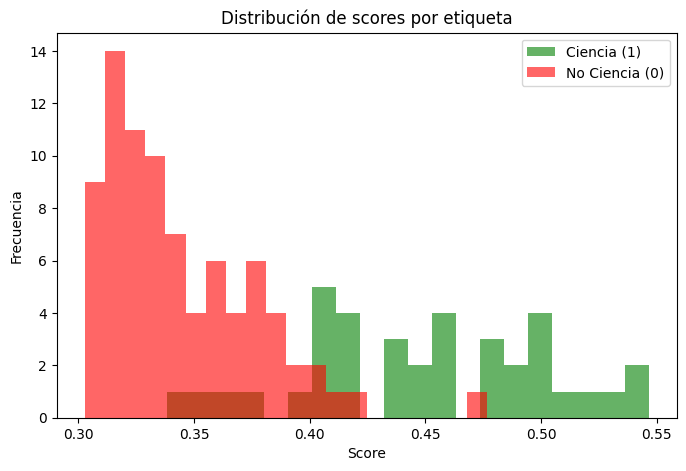

In [11]:
plt.figure(figsize=(8,5))
plt.hist(
    df_etiquetado[df_etiquetado["valido_ciencia"]==1]["score"], 
    bins=20, alpha=0.6, label="Ciencia (1)", color="green"
)
plt.hist(
    df_etiquetado[df_etiquetado["valido_ciencia"]==0]["score"], 
    bins=20, alpha=0.6, label="No Ciencia (0)", color="red"
)
plt.xlabel("Score")
plt.ylabel("Frecuencia")
plt.legend()
plt.title("Distribución de scores por etiqueta")
plt.show()

In [12]:
# Crear figura
plt.figure(figsize=(8,5))
plt.hist(
    df_etiquetado[df_etiquetado["valido_ciencia"]==1]["score"], 
    bins=20, alpha=0.6, label="Ciencia (1)", color="green"
)
plt.hist(
    df_etiquetado[df_etiquetado["valido_ciencia"]==0]["score"], 
    bins=20, alpha=0.6, label="No Ciencia (0)", color="red"
)
plt.xlabel("Score")
plt.ylabel("Frecuencia")
plt.legend()
plt.title("Distribución de scores por etiqueta")

# Guardar la figura
plt.tight_layout()
plt.savefig("../reports/ideas PAPERS/figures/distribucion_scores.png", dpi=300)
plt.close()

# 9. Encontrar el mejor umbral

In [13]:
umbrales = np.linspace(0, 1, 101)
mejor_umbral = None
mejor_acc = 0
resultados = []

for u in umbrales:
    pred = (df_etiquetado["score"] >= u).astype(int)
    acc = (pred == df_etiquetado["valido_ciencia"]).mean()
    resultados.append((u, acc))
    if acc > mejor_acc:
        mejor_acc = acc
        mejor_umbral = u

print(f"Mejor umbral: {mejor_umbral:.2f} con accuracy = {mejor_acc:.3f}")

Mejor umbral: 0.40 con accuracy = 0.916


In [15]:
umbrales

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99, 1.  ])

# 10. Graficar accuracy por umbral

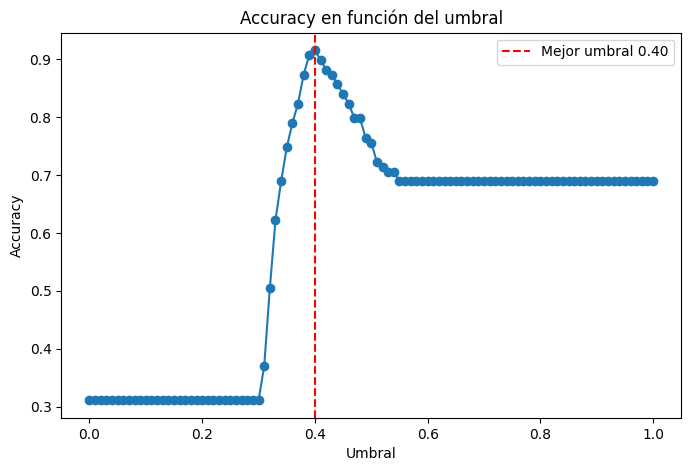

In [14]:
plt.figure(figsize=(8,5))
plt.plot([r[0] for r in resultados], [r[1] for r in resultados], marker="o")
plt.axvline(mejor_umbral, color="red", linestyle="--", label=f"Mejor umbral {mejor_umbral:.2f}")
plt.xlabel("Umbral")
plt.ylabel("Accuracy")
plt.title("Accuracy en función del umbral")
plt.legend()
plt.show()

In [9]:
plt.figure(figsize=(8,5))
plt.plot([r[0] for r in resultados], [r[1] for r in resultados], marker="o")
plt.axvline(mejor_umbral, color="red", linestyle="--", label=f"Mejor umbral {mejor_umbral:.2f}")
plt.xlabel("Umbral")
plt.ylabel("Accuracy")
plt.title("Accuracy en función del umbral")
plt.legend()
# Guardar la figura
plt.tight_layout()
plt.savefig("../reports/ideas PAPERS/figures/accuracy_umbral.png", dpi=300)
plt.close()